In [2]:
import mitsuba as mi
mi.set_variant('llvm_ad_rgb')

from sionna.rt import *

solver = PathSolver()

print(type(solver))

print(dir(solver))

import sionna
print(sionna.__version__)
help(PathSolver)

<class 'sionna.rt.path_solvers.path_solver.PathSolver'>
['__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_candidate_generator', '_field_calculator', '_image_method', 'loop_mode']
1.2.2
Help on class PathSolver in module sionna.rt.path_solvers.path_solver:

class PathSolver(builtins.object)
 |  Class implementing a path solver
 |  
 |  A path solver computes propagation paths between the antennas of
 |  all transmitters and receivers in the a scene.
 |  For each propagation path :math:`i`, the corresponding channel coefficient
 |  :math:`a_i` and delay :math:`\tau_i`, the
 |  angles of departure :math:`(\theta_{\text{T},i}, \varphi_{\text{T},i})`
 |  and arrival :math:`(\theta_{\text

In [14]:
import mitsuba as mi
import sionna
import drjit

print(mi.variant())
print(sionna.__version__)
print(drjit.__version__)
print(mi.scalar_rgb)

llvm_ad_mono_polarized
1.2.2
1.3.1
<module 'mitsuba.scalar_rgb' from '/home/yujaerim/miniconda3/envs/sionna/lib/python3.10/site-packages/mitsuba/scalar_rgb.cpython-310-x86_64-linux-gnu.so'>


In [2]:
import os

!export DRJIT_DISABLE_OPTIX=1
print(os.environ.get("DRJIT_DISABLE_OPTIX"))

None


In [15]:
import mitsuba as mi

mi.set_variant("llvm_ad_mono_polarized")

import sionna.rt
from sionna.rt import *

scene = load_scene(sionna.rt.scene.munich)

scene.preview()

In [16]:
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

tx = Transmitter(
    name="tx",
    position=[8.5, 21, 27]
)

rx = Receiver(
    name="rx",
    position=[65, 90, 1.5]
)

scene.add(tx)
scene.add(rx)

scene.preview()

In [17]:
from sionna.rt import PathSolver

# 1. 전파 경로(Ray Tracing) 계산 - 최신 API 적용
# PathSolver 인스턴스를 생성한 뒤 맵(scene) 정보를 넘겨줌
solver = PathSolver()

paths = solver(
    scene=scene,
    max_depth=300
)

print(paths)

scene.preview(paths=paths)

In [18]:
import numpy as np

# 1. 튜플 언패킹: 진폭(a)과 지연시간(tau) 분리
a, tau = paths.cir()

# 2. NumPy 배열로 변환 (Sionna 텐서를 변환)
a_np = np.array(a)
tau_np = np.array(tau)

# 3. 데이터 형태(Shape) 확인 
# 보통 [batch size, num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths] 형태를 가짐
print("Amplitude shape:", a_np.shape)
print("Delay shape:", tau_np.shape)

# 4. 파이토치 학습을 위해 파일로 저장
np.save('csi_amplitude.npy', a_np)
np.save('csi_delay.npy', tau_np)

print("✅ 학습용 데이터 추출 및 저장 완료!")

Amplitude shape: (2, 1, 1, 1, 1, 72, 1)
Delay shape: (1, 1, 72)
✅ 학습용 데이터 추출 및 저장 완료!


In [19]:
print(a_np.dtype)
print(a_np[0,0,0,0,0,:10,0])
print(tau_np[0,0,:10])

float32
[-7.4870652e-09  4.1281945e-07  1.1365767e-06 -2.8095260e-06
  4.9218514e-08  4.7310544e-07 -2.3743557e-07 -1.7236513e-07
 -2.0108309e-06 -3.1236341e-10]
[1.1580078e-06 4.2156142e-07 3.3228531e-07 9.3654791e-07 3.3552669e-07
 4.1323881e-07 6.8600463e-07 1.2547832e-06 9.3727107e-07 6.7312800e-07]


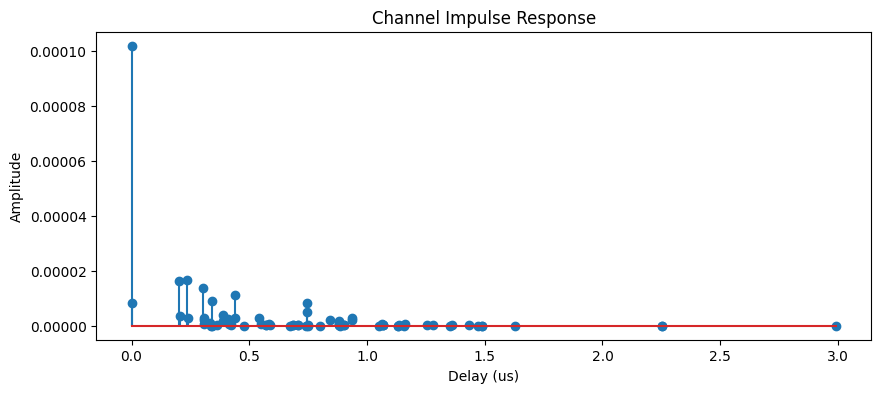

In [20]:
import matplotlib.pyplot as plt

amp = np.abs(a_np[0,0,0,0,0,:,0])

plt.figure(figsize=(10,4))
plt.stem(tau_np[0,0,:]*1e6, amp)
plt.xlabel("Delay (us)")
plt.ylabel("Amplitude")
plt.title("Channel Impulse Response")
plt.show()

In [21]:
import numpy as np

# 저장했던 데이터 불러오기 (모양을 맞추기 위해 squeeze로 불필요한 차원 제거)
a_np = np.load('csi_amplitude.npy').squeeze() # (100,) 복소수 진폭
tau_np = np.load('csi_delay.npy').squeeze()   # (100,) 지연 시간

# ESP32-S3 Wi-Fi 설정 (예: 20MHz 대역폭, 64개 서브캐리어)
num_subcarriers = 64
bandwidth = 20e6 # 20 MHz
subcarrier_spacing = bandwidth / num_subcarriers
frequencies = np.arange(-num_subcarriers//2, num_subcarriers//2) * subcarrier_spacing

# 시간 도메인(Ray) -> 주파수 도메인(OFDM CSI) 변환
csi_matrix = np.zeros(num_subcarriers, dtype=np.complex128)

for i, f in enumerate(frequencies):
    # 각 서브캐리어 주파수마다 100개의 경로(Path) 영향을 모두 합산 (푸리에 변환)
    phase_shift = np.exp(-1j * 2 * np.pi * f * tau_np)
    csi_matrix[i] = np.sum(a_np * phase_shift)

# AI가 학습하기 좋게 크기(Magnitude)와 위상(Phase)으로 분리
csi_magnitude = np.abs(csi_matrix)
csi_phase = np.angle(csi_matrix)

# 최종적으로 모델에 들어갈 1D 텐서 (크기 + 위상 결합)
csi_feature = np.concatenate([csi_magnitude, csi_phase]) 
print("AI 모델 입력 형태:", csi_feature.shape) # (128,) 형태가 됨

AI 모델 입력 형태: (128,)


In [24]:
print(type(scene.objects))
print(scene.objects.keys())

for k,v in scene.objects.items():
    print(k, type(v))

<class 'dict'>
dict_keys(['Heilig_Geist-itu_marble', 'Heilig_Geist-itu_metal', 'Frauenkirche-itu_marble', 'Frauenkirche-itu_metal', 'St__Peter-itu_marble', 'St__Peter-itu_metal', 'ground', 'no-name-5', 'no-name-6', 'no-name-7', 'no-name-8'])
Heilig_Geist-itu_marble <class 'sionna.rt.scene_object.SceneObject'>
Heilig_Geist-itu_metal <class 'sionna.rt.scene_object.SceneObject'>
Frauenkirche-itu_marble <class 'sionna.rt.scene_object.SceneObject'>
Frauenkirche-itu_metal <class 'sionna.rt.scene_object.SceneObject'>
St__Peter-itu_marble <class 'sionna.rt.scene_object.SceneObject'>
St__Peter-itu_metal <class 'sionna.rt.scene_object.SceneObject'>
ground <class 'sionna.rt.scene_object.SceneObject'>
no-name-5 <class 'sionna.rt.scene_object.SceneObject'>
no-name-6 <class 'sionna.rt.scene_object.SceneObject'>
no-name-7 <class 'sionna.rt.scene_object.SceneObject'>
no-name-8 <class 'sionna.rt.scene_object.SceneObject'>


In [23]:
scene.remove("Heilig_Geist-itu_marble")
scene.remove("Heilig_Geist-itu_metal")
scene.remove("Frauenkirche-itu_marble")
scene.remove("Frauenkirche-itu_metal")
scene.remove("St__Peter-itu_marble")
scene.remove("St__Peter-itu_metal")

TypeError: Only Transmitters, Receivers, or RadioMaterials can be removed